In [ ]:
# Data collection command:
# `python comet_download.py --project=ns-autostep-feature-search-hyper-sweep --n_threads=8`

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load Data

In [3]:
save_path = 'figures/'
config_data_path = 'data/ns-autostep-feature-search-hyper-sweep_params.csv'
run_data_path = 'data/ns-autostep-feature-search-hyper-sweep_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
del config_dfs[np.nan], run_dfs[np.nan]
{k: len(v) for k, v in config_dfs.items()}

{'perfect_features_baseline_sweep': 125,
 'baseline_hyper_sweep': 2497,
 'maturity_threshold_hyper_sweep': 3594,
 'maturity_threshold_hyper_sweep_v2': 300}

In [4]:
print("_____Best Hyperparameter Configurations_____")
best_config_dfs, best_run_dfs = get_best_ablation_values(config_dfs, run_dfs)
{k: len(v) for k, v in best_config_dfs.items()}

_____Best Hyperparameter Configurations_____

=== perfect_features_baseline_sweep ===

Configuration: (no split vars)
  Best optimizer.meta_learning_rate=${eval:2**-5}
  Best optimizer.learning_rate=${eval:2**-3}


=== baseline_hyper_sweep ===

Configuration: (no split vars)
  Best optimizer.meta_learning_rate=${eval:2**-5}
  Best feature_recycling.utility_decay=0.9999
  Best optimizer.learning_rate=${eval:2**-14}
  Best feature_recycling.recycle_rate=0.001


=== maturity_threshold_hyper_sweep ===

Configuration: (no split vars)
  Best feature_recycling.recycle_rate=0.001
  Best optimizer.learning_rate=${eval:2**-14}
  Best feature_recycling.feature_protection_steps=100.0
  Best optimizer.meta_learning_rate=${eval:2**-5}
  Best feature_recycling.utility_decay=0.999


=== maturity_threshold_hyper_sweep_v2 ===

Configuration: (no split vars)
  Best feature_recycling.feature_protection_steps=0.0
  Best feature_recycling.utility_decay=0.999
  Best feature_recycling.recycle_rate=0.005



{'perfect_features_baseline_sweep': 5,
 'baseline_hyper_sweep': 5,
 'maturity_threshold_hyper_sweep': 5,
 'maturity_threshold_hyper_sweep_v2': 5}

## Comparison

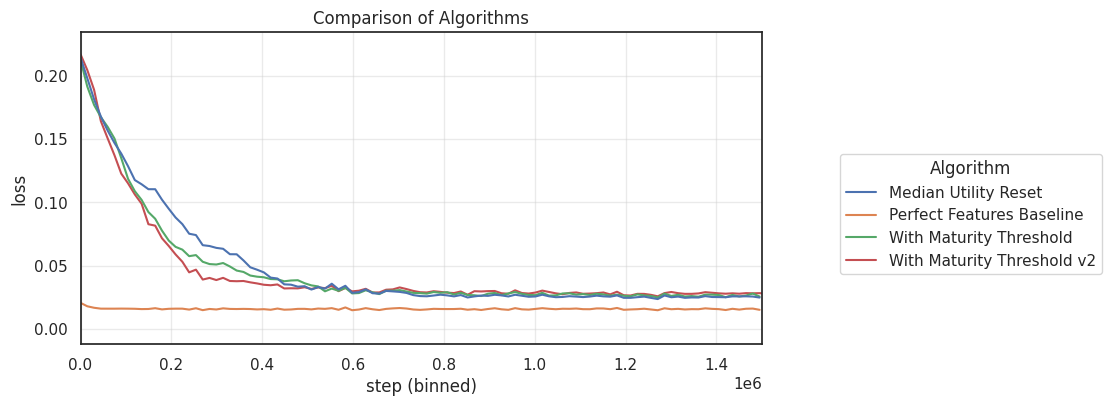

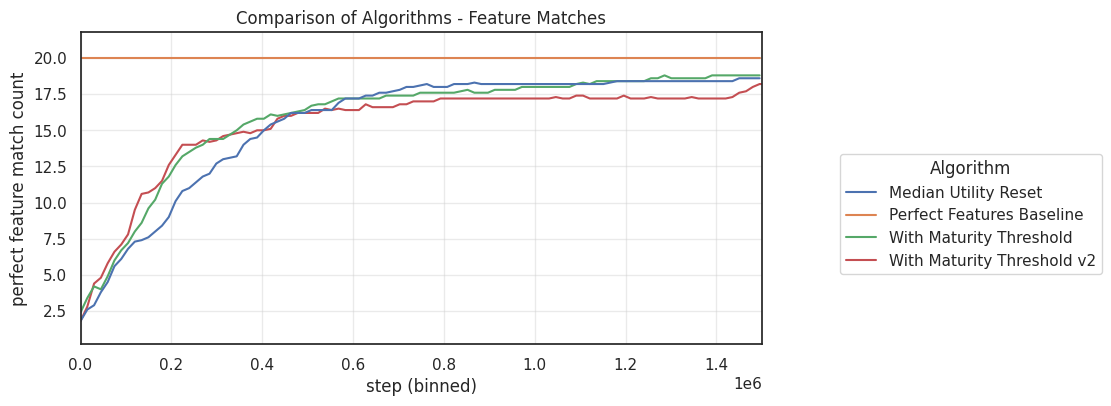

In [20]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'baseline_hyper_sweep': 'Median Utility Reset',
    'maturity_threshold_hyper_sweep': 'With Maturity Threshold',
    'maturity_threshold_hyper_sweep_v2': 'With Maturity Threshold v2',
    'perfect_features_baseline_sweep': 'Perfect Features Baseline'
}
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()

## Baseline Performance & Hyperparam Sensitivity

Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

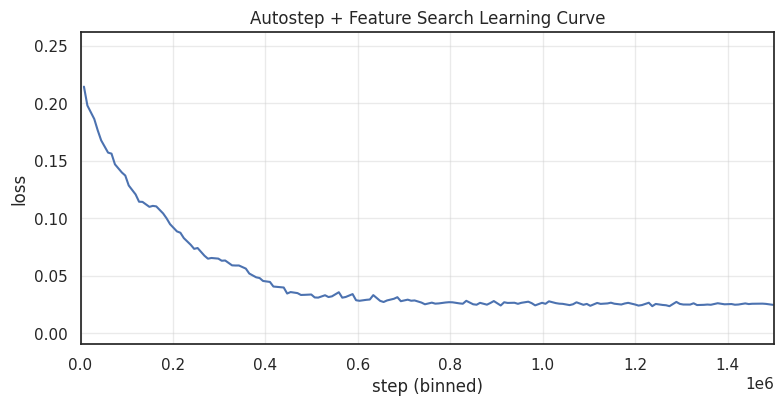

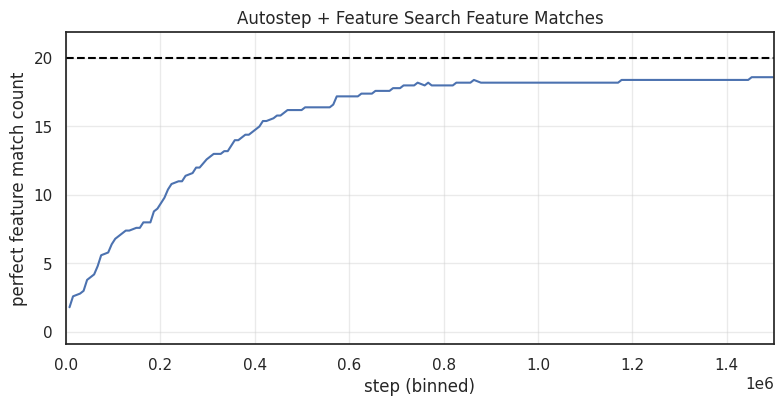

In [8]:
plot_learning_curves(
    run_df = best_run_dfs['baseline_hyper_sweep'],
    config_df = best_config_dfs['baseline_hyper_sweep'],
    n_bins = 200,
    figsize = (8, 4),
)
plt.title('Autostep + Feature Search Learning Curve')

plot_learning_curves(
    run_df = best_run_dfs['baseline_hyper_sweep'],
    config_df = best_config_dfs['baseline_hyper_sweep'],
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')

plt.title('Autostep + Feature Search Feature Matches')

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


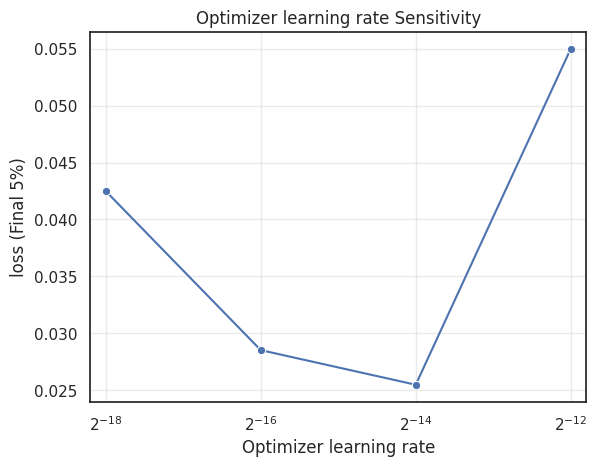

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


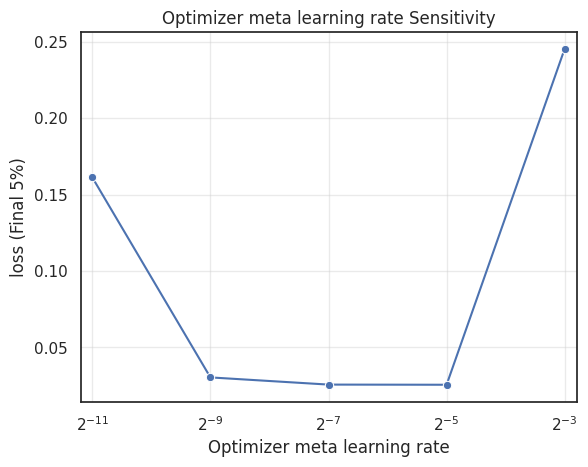

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


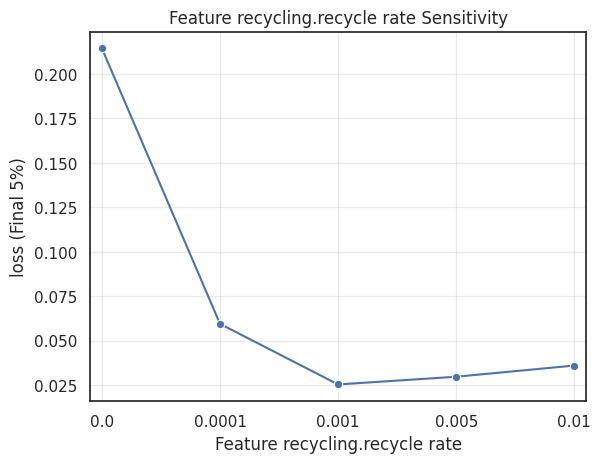

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


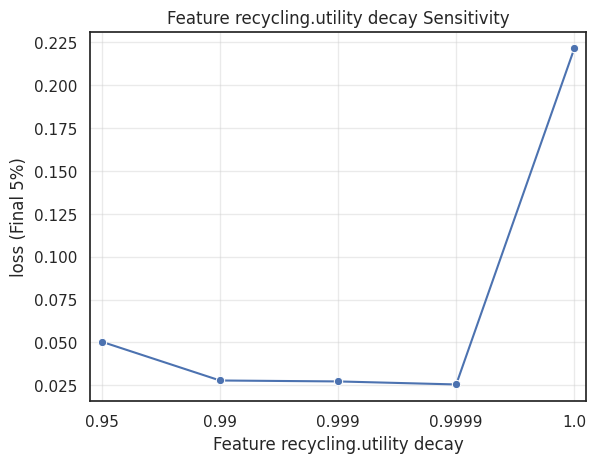

In [9]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-14,
    'optimizer|meta_learning_rate': 2**-5,
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.9999,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['baseline_hyper_sweep'],
        config_df = config_dfs['baseline_hyper_sweep'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()

## With Maturity Threshold

Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

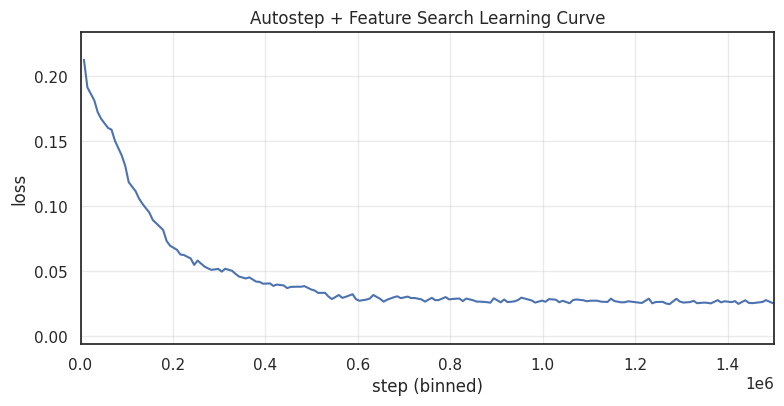

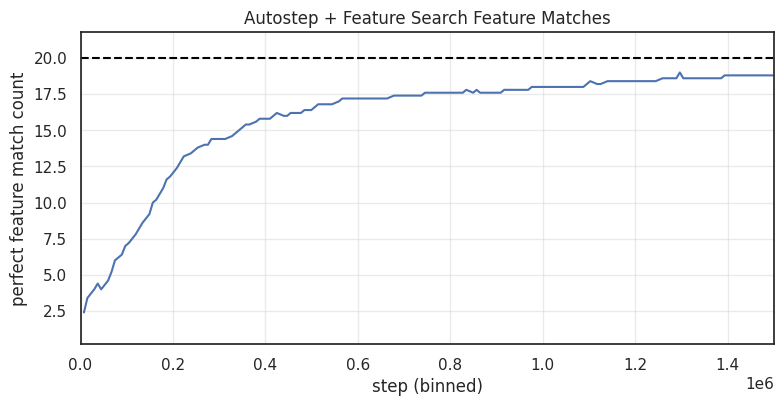

In [10]:
plot_learning_curves(
    run_df = best_run_dfs['maturity_threshold_hyper_sweep'],
    config_df = best_config_dfs['maturity_threshold_hyper_sweep'],
    n_bins = 200,
    figsize = (8, 4),
)
plt.title('Autostep + Feature Search Learning Curve')

plot_learning_curves(
    run_df = best_run_dfs['maturity_threshold_hyper_sweep'],
    config_df = best_config_dfs['maturity_threshold_hyper_sweep'],
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')

plt.title('Autostep + Feature Search Feature Matches')

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


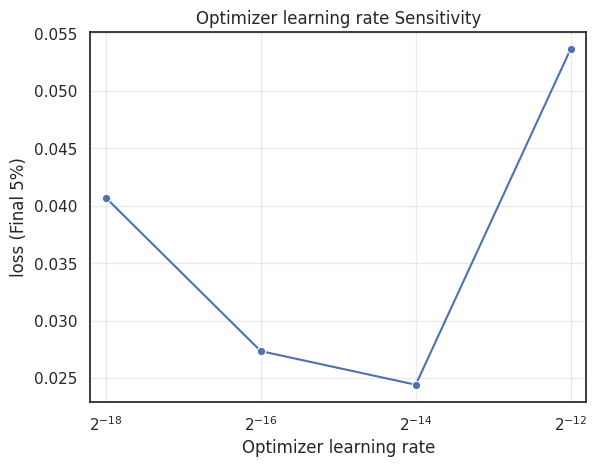

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


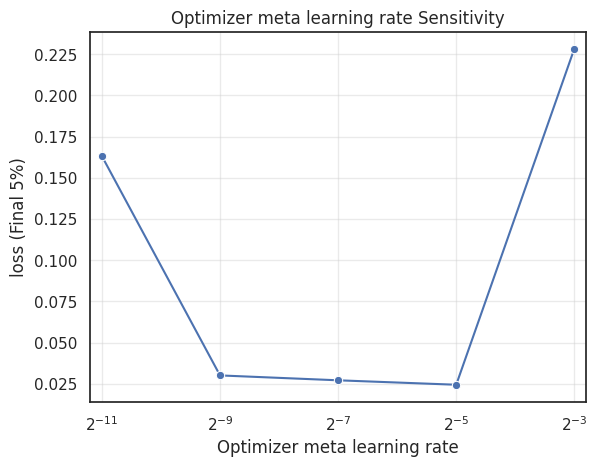

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


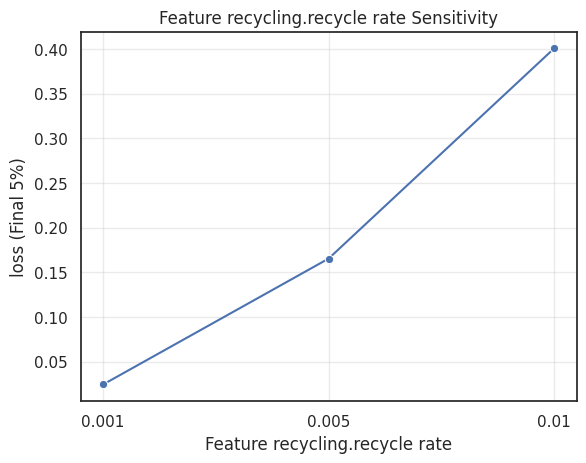

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


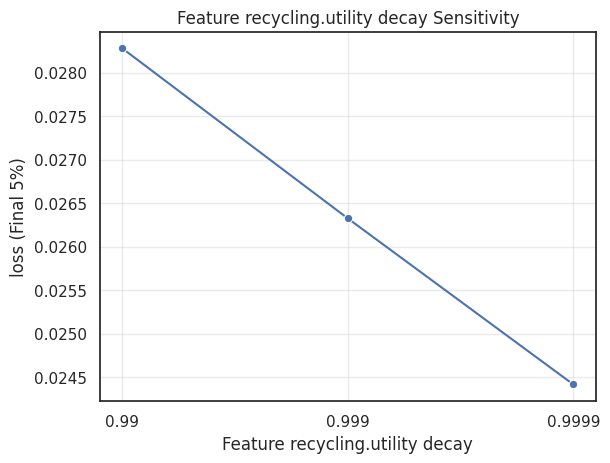

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


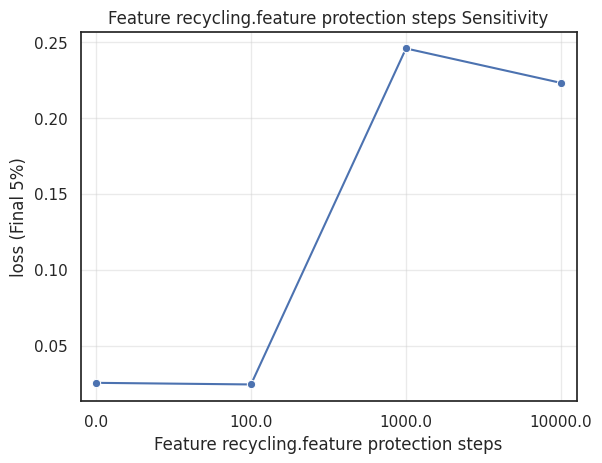

In [11]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-14,
    'optimizer|meta_learning_rate': 2**-5,
    'feature_recycling.recycle_rate': 0.001,
    'feature_recycling.utility_decay': 0.9999,
    'feature_recycling.feature_protection_steps': 100.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['maturity_threshold_hyper_sweep'],
        config_df = config_dfs['maturity_threshold_hyper_sweep'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()

## With Maturity Threshold v2

Text(0.5, 1.0, 'Autostep + Feature Search Feature Matches')

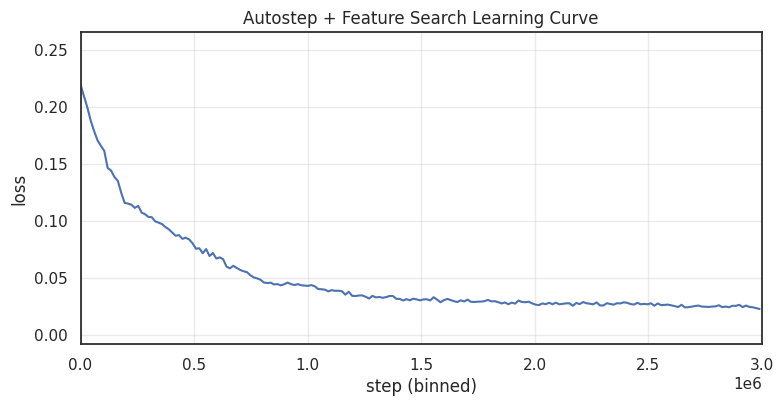

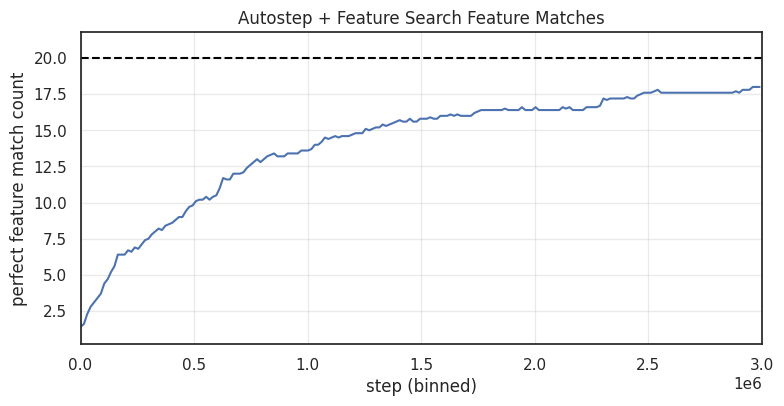

In [18]:
best_hyperparams = {
    'feature_recycling.recycle_rate': 0.005,
    'feature_recycling.utility_decay': 0.99999,
    'feature_recycling.feature_protection_steps': 0.0,
}
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['maturity_threshold_hyper_sweep_v2'],
    config_df = config_dfs['maturity_threshold_hyper_sweep_v2'],
    chosen_values = best_hyperparams,
)

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (8, 4),
)
plt.title('Autostep + Feature Search Learning Curve')

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    n_bins = 200,
    figsize = (8, 4),
)
plt.axhline(20, color='black', linestyle='--')

plt.title('Autostep + Feature Search Feature Matches')

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


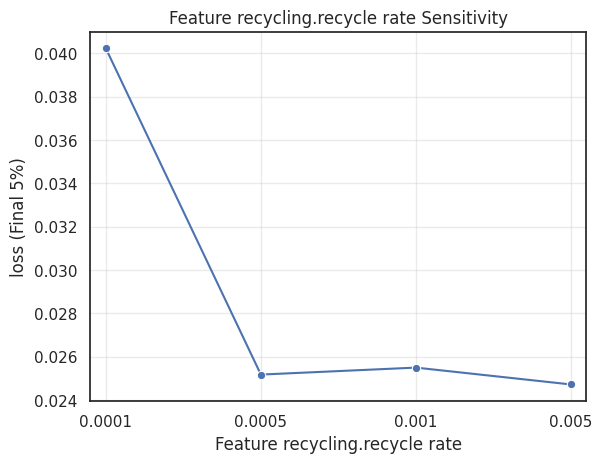

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


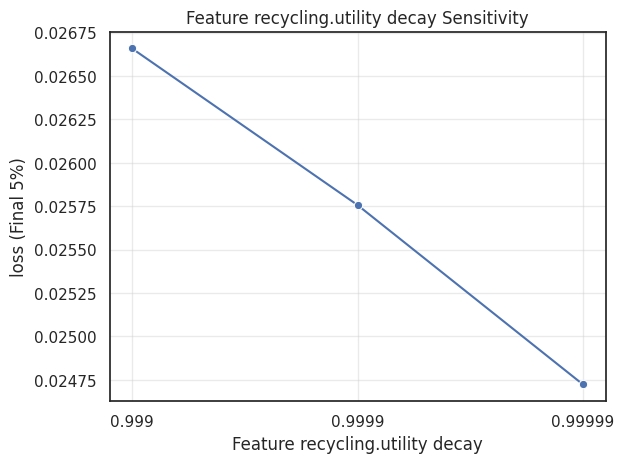

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


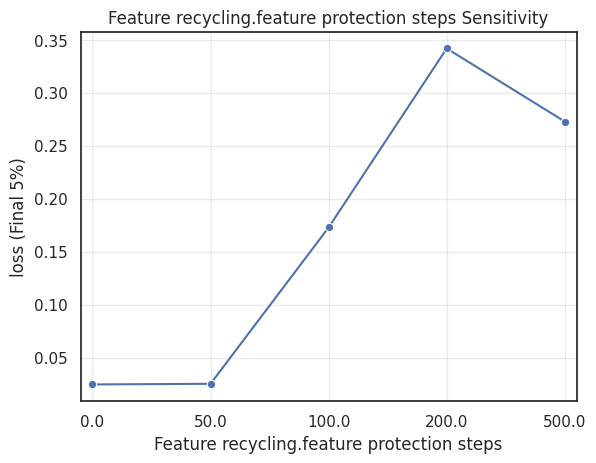

In [17]:
default_hyperparams = {
    'feature_recycling.recycle_rate': 0.005,
    'feature_recycling.utility_decay': 0.99999,
    'feature_recycling.feature_protection_steps': 0.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['maturity_threshold_hyper_sweep_v2'],
        config_df = config_dfs['maturity_threshold_hyper_sweep_v2'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()